## Cell 1: Imports & Setup

In [1]:
# ── Imports & Setup ───────────────────────────────────────────────────────────
import random, os, copy, time, json, re
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import google.generativeai as genai

from tqdm.auto import tqdm
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from transformers import AutoTokenizer, AutoModelForCausalLM



ModuleNotFoundError: No module named 'matplotlib'

## Cell 2: Configuration (ExperimentConfig)

**V4 changes vs V3:**
- `base_dir` points to V4 folder
- Architecture 4 only (best in V3)
- New `test_csv` → `Entities_QA_Test_V4.csv` (14 categories, no entity overlap with train)
- New `train2_csv` → `Entities_QA_Train2_V4.csv` (unseen entities for GRPO generalization)
- Added GRPO Phase 2 hyperparameters (`grpo_epochs`, `grpo_lr`, `grpo_batch_size`, `grpo_num_generations`, `grpo_reward_weights`)
- GRPO reward uses local Qwen-2.5-3B-Instruct judge (contains_entity + matches_reference)
- Added `grpo_train_per_entity` (2) for Train 1 sampling and `grpo_kl_coeff` for KL penalty

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
@dataclass
class ExperimentConfig:
    # --- Model ---
    model_name:  str         = "meta-llama/Llama-3.1-8B-Instruct"
    device_map:  str         = "auto"
    torch_dtype: torch.dtype = torch.bfloat16

    # --- Paths (V4 folder) ---
    base_dir: str = (
        "results_v4"
    )

    # --- Extraction ---
    extraction_layer:  int  = 16
    extraction_pos:    str  = "resid_post"
    normalize_vectors: bool = True

    # --- Injection ---
    injection_layer: int = 16

    # --- Architecture (V4: architecture 4 only) ---
    architecture_id:    int = 4
    adapter_hidden_dim: int = 4096   # 2-layer MLP hidden size

    # --- Training ---
    train_ratio:   float = 0.8
    seed:          int   = 42
    use_lowercase: bool  = True
    prompt_id:     int   = 1

    # --- Phase 1: Weighted CE + BERTTune ---
    phase1_epochs:        int   = 20
    phase1_lr:            float = 5e-4
    phase1_batch_size:    int   = 16
    phase1_dropout:       float = 0.15
    entity_token_weight:  float = 8.0
    berttune_lambda:      float = 3.0
    berttune_temperature: float = 1.0

    # --- Phase 2: GRPO with Qwen Judge Reward ---
    grpo_epochs:          int   = 5
    grpo_lr:              float = 1e-5
    grpo_batch_size:      int   = 4
    grpo_num_generations: int   = 4     # G: number of generations per prompt
    grpo_max_new_tokens:  int   = 128
    grpo_temperature:     float = 0.7   # sampling temperature for generation
    grpo_kl_coeff:        float = 0.05  # KL penalty coefficient
    grpo_train_per_entity: int  = 2     # examples per entity for Train 1
    grpo_reward_weights:  Dict[str, float] = field(default_factory=lambda: {
        "contains_entity": 0.5,
        "matches_reference": 0.5,
    })
    judge_model_name: str = "Qwen/Qwen2.5-3B-Instruct"

    # --- Multi-prompt QA-style extraction ---
    extraction_prompts: List[str] = field(default_factory=lambda: [
        "Q: What is {word}? A:",
        "Q: Describe {word}. A:",
        "Q: Tell me about {word}. A:",
        "Q: What do you know about {word}? A:",
    ])

    # Populated dynamically from CSV
    words: List[str] = field(default_factory=list)

    def get_safe_model_name(self):
        return self.model_name.replace("/", "_")

    @property
    def cache_dir(self):
        p = os.path.join(self.base_dir, "learning_cache")
        os.makedirs(p, exist_ok=True)
        return p

    @property
    def adapter_save_path(self):
        p = os.path.join(self.base_dir, "trained_adapters")
        os.makedirs(p, exist_ok=True)
        fname = (f"adapter_{self.get_safe_model_name()}"
                 f"_L{self.injection_layer}_architecture{self.architecture_id}.pt")
        return os.path.join(p, fname)

    @property
    def adapter_save_path_grpo(self):
        p = os.path.join(self.base_dir, "trained_adapters")
        os.makedirs(p, exist_ok=True)
        fname = (f"adapter_{self.get_safe_model_name()}"
                 f"_L{self.injection_layer}_architecture{self.architecture_id}_grpo.pt")
        return os.path.join(p, fname)

    @property
    def train_csv(self):
        return os.path.join(self.base_dir, "Entities_QA.csv")

    @property
    def test_csv(self):
        return os.path.join(self.base_dir, "Entities_QA_Test_V4.csv")

    @property
    def train2_csv(self):
        return os.path.join(self.base_dir, "Entities_QA_Train2_V4.csv")


cfg = ExperimentConfig()
print(f"Base dir:             {cfg.base_dir}")
print(f"Architecture:         {cfg.architecture_id}")
print(f"Entity weight:        {cfg.entity_token_weight}x")
print(f"BERTTune lambda:      {cfg.berttune_lambda}")
print(f"GRPO epochs:          {cfg.grpo_epochs}")
print(f"GRPO reward weights:  {cfg.grpo_reward_weights}")
print(f"Judge model:          {cfg.judge_model_name}")

Base dir:             results_v4
Architecture:         4
Entity weight:        8.0x
BERTTune lambda:      3.0
GRPO epochs:          5
GRPO reward weights:  {'contains_entity': 0.5, 'matches_reference': 0.5}
Judge model:          Qwen/Qwen2.5-3B-Instruct


## Cell 3: Concept Vector Extraction (Multi-Prompt QA-style, Averaged)

Extracts from 4 QA-style prompts per entity and averages the vectors. Cached to disk.

In [3]:
# ── Concept Vector Extraction (Multi-Prompt QA-style, Averaged) ───────────────

@torch.inference_mode()
def get_layer_activation(model, tokenizer, prompt: str,
                          layer_idx: int, which: str = "resid_post") -> torch.Tensor:
    tokenizer.padding_side = "right"
    enc = tokenizer(prompt, return_tensors="pt", padding=True,
                    truncation=True, add_special_tokens=True)
    enc = {k: v.to(model.device) for k, v in enc.items()}
    out = model(**enc, output_hidden_states=True, use_cache=False)
    hs  = out.hidden_states
    acts = hs[layer_idx + 1] if which == "resid_post" else hs[layer_idx]
    length = enc["attention_mask"].sum(dim=1) - 1
    return acts[0, length[0]].detach().cpu()


def get_concept_vectors(cfg: ExperimentConfig, model, tokenizer,
                        split_tag: str = "train") -> dict:
    norm_tag = "norm" if cfg.normalize_vectors else "raw"
    filename = (f"{split_tag}_concepts_{cfg.get_safe_model_name()}_L{cfg.extraction_layer}"
                f"_{cfg.extraction_pos}_{norm_tag}_multiQA_p{cfg.prompt_id}.pt")
    filepath = os.path.join(cfg.cache_dir, filename)

    if os.path.exists(filepath):
        print(f"Loading concept vectors from cache: {filepath}")
        data = torch.load(filepath, map_location="cpu")
        return data["vectors"]

    print(f"Computing concept vectors for {len(cfg.words)} entities "
          f"using {len(cfg.extraction_prompts)} prompts each...")
    concept_vecs = {}

    for word in tqdm(set(cfg.words), desc="Concept Vectors"):
        key  = word.lower() if cfg.use_lowercase else word
        vecs = []
        for tmpl in cfg.extraction_prompts:
            prompt = tmpl.replace("{word}", word)
            vec = get_layer_activation(model, tokenizer, prompt,
                                       cfg.extraction_layer, cfg.extraction_pos)
            vecs.append(vec)
        avg_vec = torch.stack(vecs).mean(dim=0)
        if cfg.normalize_vectors:
            avg_vec = F.normalize(avg_vec, dim=-1)
        concept_vecs[key] = avg_vec

    torch.save({"words": list(concept_vecs.keys()), "vectors": concept_vecs}, filepath)
    print(f"Saved concept vectors to: {filepath}")
    return concept_vecs

## Cell 4: Adapter Architecture 4 (2-layer MLP)

Architecture 4 was the best performer in V3. Simple 2-layer MLP: `input_dim → hidden_dim → GELU → Dropout → input_dim`.

In [4]:
# ── Adapter Architecture 4 (2-layer MLP) ──────────────────────────────────────

class InjectionAdapterV4(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 4096, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def build_adapter(cfg: ExperimentConfig, model) -> nn.Module:
    input_dim = model.config.hidden_size
    adapter = InjectionAdapterV4(
        input_dim=input_dim,
        hidden_dim=cfg.adapter_hidden_dim,
        dropout=cfg.phase1_dropout,
    )
    n_params = sum(p.numel() for p in adapter.parameters())
    print(f"Adapter (Architecture {cfg.architecture_id}): {n_params:,} parameters")
    return adapter

## Cell 5: Data Processing

- `process_data`: Loads `Entities_QA.csv`, stratified train/val split (same as V3).
- `load_test_data`: Loads `Entities_QA_Test_V4.csv` (now has Category column — no more renaming).
- `load_train2_data`: Loads `Entities_QA_Train2_V4.csv` (unseen entities for GRPO).
- `build_grpo_data`: Samples 2 examples/entity from the train split (Train 1) and concatenates with all Train 2 data to form the combined GRPO training set.

In [5]:
# ── Data Processing ───────────────────────────────────────────────────────────

def process_data(cfg: ExperimentConfig, tokenizer):
    print(f"Loading data from: {cfg.train_csv}")
    df = pd.read_csv(cfg.train_csv)

    required = ['Category', 'Entity', 'Question', 'Answer']
    if not all(c in df.columns for c in required):
        raise ValueError(f"CSV must have columns: {required}. Found: {list(df.columns)}")

    valid_data   = []
    unique_words = set()

    for _, row in df.iterrows():
        category = str(row['Category'])
        entity   = str(row['Entity'])
        question = str(row['Question'])
        answer   = str(row['Answer'])

        entity_key   = entity.lower()   if cfg.use_lowercase else entity
        category_key = category.lower() if cfg.use_lowercase else category
        unique_words.add(entity)

        valid_data.append({
            "category_key":    category_key,
            "entity_key":      entity_key,
            "entity_original": entity,
            "question":        question,
            "answer":          answer,
        })

    cfg.words = list(unique_words)
    print(f"Entities: {len(cfg.words)} | Examples: {len(valid_data)}")

    # Stratified split by (category, entity)
    random.seed(cfg.seed)
    train_data, val_data = [], []
    grouped = {}
    for item in valid_data:
        grouped.setdefault((item['category_key'], item['entity_key']), []).append(item)

    for key, examples in grouped.items():
        val_example = random.choice(examples)
        val_data.append(val_example)
        train_data.extend([e for e in examples if e != val_example])

    random.shuffle(train_data)
    random.shuffle(val_data)
    print(f"Train: {len(train_data)} | Val: {len(val_data)}")
    return train_data, val_data


def load_test_data(cfg: ExperimentConfig) -> List[dict]:
    print(f"Loading test data from: {cfg.test_csv}")
    df = pd.read_csv(cfg.test_csv)
    data = []
    for _, row in df.iterrows():
        entity   = str(row['Entity'])
        category = str(row.get('Category', 'unknown_category'))
        data.append({
            "category_key":    category.lower() if cfg.use_lowercase else category,
            "entity_key":      entity.lower() if cfg.use_lowercase else entity,
            "entity_original": entity,
            "question":        str(row['Question']),
            "answer":          str(row['Answer']),
        })
    print(f"Test examples: {len(data)}")
    return data


def load_train2_data(cfg: ExperimentConfig) -> List[dict]:
    print(f"Loading Train 2 data from: {cfg.train2_csv}")
    df = pd.read_csv(cfg.train2_csv)
    data = []
    for _, row in df.iterrows():
        entity   = str(row['Entity'])
        category = str(row.get('Category', 'unknown_category'))
        data.append({
            "category_key":    category.lower() if cfg.use_lowercase else category,
            "entity_key":      entity.lower() if cfg.use_lowercase else entity,
            "entity_original": entity,
            "question":        str(row['Question']),
            "answer":          str(row['Answer']),
        })
    print(f"Train 2 examples: {len(data)}")
    return data


def build_grpo_data(train_data: List[dict], train2_data: List[dict],
                    cfg: ExperimentConfig) -> List[dict]:
    # Train 1: sample `grpo_train_per_entity` examples per entity from the Phase 1 train split.
    random.seed(cfg.seed)
    grouped = {}
    for item in train_data:
        grouped.setdefault(item['entity_key'], []).append(item)

    train1_sampled = []
    for entity_key, examples in grouped.items():
        k = min(cfg.grpo_train_per_entity, len(examples))
        train1_sampled.extend(random.sample(examples, k))

    # Combine Train 1 (seen, sampled) + Train 2 (unseen, all)
    grpo_data = train1_sampled + train2_data
    random.shuffle(grpo_data)

    n_seen   = len(train1_sampled)
    n_unseen = len(train2_data)
    print(f"GRPO data: {len(grpo_data)} total "
          f"(Train 1: {n_seen} seen, Train 2: {n_unseen} unseen)")
    return grpo_data

## Cell 6: BERTTune Semantic Loss

Same as V3. Uses LLaMA's own embedding matrix for differentiable soft embeddings.

In [6]:
# ── BERTTune Semantic Loss ────────────────────────────────────────────────────

def berttune_semantic_loss(
    logits:       torch.Tensor,
    target_ids:   torch.Tensor,
    embed_matrix: torch.Tensor,
    answer_mask:  torch.Tensor,
    temperature:  float = 1.0,
) -> torch.Tensor:
    B, T, V = logits.shape

    probs     = F.softmax(logits.float() / temperature, dim=-1)
    soft_embs = probs @ embed_matrix.float()

    with torch.no_grad():
        ref_embs = embed_matrix.float()[target_ids.clamp(min=0)]

    mask      = answer_mask.float().unsqueeze(-1)
    soft_embs = soft_embs * mask
    ref_embs  = ref_embs  * mask

    denom     = mask.sum(dim=1).clamp(min=1e-8)
    soft_mean = soft_embs.sum(dim=1) / denom
    ref_mean  = ref_embs.sum(dim=1)  / denom

    cos_sim = F.cosine_similarity(soft_mean, ref_mean, dim=-1)
    return 1.0 - cos_sim.mean()

## Cell 7: Training Helpers

Entity span detection, injection hook factory, and `build_batch`.

In [7]:
# ── Training Helpers ──────────────────────────────────────────────────────────

def find_entity_token_spans(answer_ids: List[int], entity_ids: List[int]) -> List[int]:
    positions = []
    n, m = len(answer_ids), len(entity_ids)
    if m == 0:
        return positions
    for i in range(n - m + 1):
        if answer_ids[i : i + m] == entity_ids:
            positions.extend(range(i, i + m))
    return positions


def make_injection_hook(injection_vecs: torch.Tensor, injection_indices: List[int]):
    def hook(module, args, output):
        hs = output[0] if isinstance(output, tuple) else output
        for b, idx in enumerate(injection_indices):
            if b < hs.shape[0] and idx < hs.shape[1]:
                hs[b, idx, :] = hs[b, idx, :] + injection_vecs[b]
        return (hs,) + output[1:] if isinstance(output, tuple) else hs
    return hook


def build_batch(items, tokenizer, cfg, concept_vecs):
    input_ids_list, labels_list, weights_list = [], [], []
    answer_masks_list, injection_indices, batch_vectors = [], [], []

    for item in items:
        vec = concept_vecs.get(item['entity_key'])
        if vec is None:
            continue

        msgs       = [{"role": "user", "content": item['question']}]
        prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False,
                                                   add_generation_prompt=True)
        answer_str = item['answer'] + tokenizer.eos_token

        prompt_ids = tokenizer.encode(prompt_str, add_special_tokens=False)
        ans_ids    = tokenizer.encode(answer_str, add_special_tokens=False)

        entity_ids = tokenizer.encode(item['entity_original'], add_special_tokens=False)
        entity_pos = set(find_entity_token_spans(ans_ids, entity_ids))
        weights    = [cfg.entity_token_weight if i in entity_pos else 1.0
                      for i in range(len(ans_ids))]

        full_ids = prompt_ids + ans_ids
        lbl_ids  = [-100] * len(prompt_ids) + ans_ids
        lbl_wts  = [0.0]  * len(prompt_ids) + weights
        ans_mask = [0.0]  * len(prompt_ids) + [1.0] * len(ans_ids)

        input_ids_list.append(torch.tensor(full_ids,  dtype=torch.long))
        labels_list.append(torch.tensor(lbl_ids,      dtype=torch.long))
        weights_list.append(torch.tensor(lbl_wts,     dtype=torch.float))
        answer_masks_list.append(torch.tensor(ans_mask, dtype=torch.float))
        injection_indices.append(len(prompt_ids) - 1)
        batch_vectors.append(vec)

    if not input_ids_list:
        return None

    pad = tokenizer.pad_token_id
    input_ids    = torch.nn.utils.rnn.pad_sequence(input_ids_list,    batch_first=True, padding_value=pad)
    labels       = torch.nn.utils.rnn.pad_sequence(labels_list,       batch_first=True, padding_value=-100)
    weights      = torch.nn.utils.rnn.pad_sequence(weights_list,      batch_first=True, padding_value=0.0)
    answer_masks = torch.nn.utils.rnn.pad_sequence(answer_masks_list, batch_first=True, padding_value=0.0)
    attn_mask    = (input_ids != pad).long()

    return {
        "input_ids":         input_ids,
        "labels":            labels,
        "weights":           weights,
        "answer_masks":      answer_masks,
        "attention_mask":    attn_mask,
        "injection_indices": injection_indices,
        "batch_vectors":     torch.stack(batch_vectors),
    }

## Cell 8: Phase 1 Training (Weighted CE + BERTTune)

Same as V3. Single supervised phase with early stopping on validation loss.

In [8]:
# ── Phase 1: Weighted CE + BERTTune Training ──────────────────────────────────

def train_phase1(cfg, model, tokenizer, adapter, train_data, val_data, concept_vecs):
    optimizer    = torch.optim.AdamW(adapter.parameters(), lr=cfg.phase1_lr)
    embed_matrix = model.model.embed_tokens.weight.detach()
    layer        = model.model.layers[cfg.injection_layer]
    history      = {"train_ce": [], "train_sem": [], "train_total": [], "val_loss": []}

    n_batches_total = (len(train_data) + cfg.phase1_batch_size - 1) // cfg.phase1_batch_size

    best_val   = float('inf')
    patience   = 3
    wait       = 0
    best_state = None

    for epoch in range(cfg.phase1_epochs):
        adapter.train()
        random.shuffle(train_data)
        total_ce, total_sem, total_loss, n_batches = 0., 0., 0., 0

        pbar = tqdm(range(0, len(train_data), cfg.phase1_batch_size),
                    desc=f"Epoch {epoch+1:02d}/{cfg.phase1_epochs}",
                    total=n_batches_total)

        for i in pbar:
            batch = build_batch(train_data[i : i + cfg.phase1_batch_size],
                                tokenizer, cfg, concept_vecs)
            if batch is None:
                continue

            dev          = model.device
            input_ids    = batch["input_ids"].to(dev)
            labels       = batch["labels"].to(dev)
            weights      = batch["weights"].to(dev)
            answer_masks = batch["answer_masks"].to(dev)
            attn_mask    = batch["attention_mask"].to(dev)

            raw_vecs       = batch["batch_vectors"].to(dev, dtype=cfg.torch_dtype)
            injection_vecs = adapter(raw_vecs)

            hook   = make_injection_hook(injection_vecs, batch["injection_indices"])
            handle = layer.register_forward_hook(hook)
            try:
                outputs = model(input_ids=input_ids, attention_mask=attn_mask,
                                use_cache=False)
            finally:
                handle.remove()

            logits = outputs.logits

            shift_logits  = logits[:, :-1, :].contiguous()
            shift_labels  = labels[:, 1:].contiguous()
            shift_weights = weights[:, 1:].contiguous()
            shift_amask   = answer_masks[:, 1:].contiguous()

            B, T, V = shift_logits.shape

            per_token_ce = F.cross_entropy(
                shift_logits.view(B * T, V),
                shift_labels.view(B * T),
                ignore_index=-100,
                reduction='none'
            ).view(B, T)
            loss_ce = (per_token_ce * shift_weights).sum() / (shift_weights.sum() + 1e-8)

            valid_answer_mask = shift_amask * (shift_labels != -100).float()
            loss_sem = berttune_semantic_loss(
                logits       = shift_logits,
                target_ids   = shift_labels.clamp(min=0),
                embed_matrix = embed_matrix,
                answer_mask  = valid_answer_mask,
                temperature  = cfg.berttune_temperature,
            )

            loss = loss_ce + cfg.berttune_lambda * loss_sem

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(adapter.parameters(), max_norm=1.0)
            optimizer.step()

            total_ce   += loss_ce.item()
            total_sem  += loss_sem.item()
            total_loss += loss.item()
            n_batches  += 1

            pbar.set_postfix({
                "CE":    f"{total_ce / n_batches:.4f}",
                "Sem":   f"{total_sem / n_batches:.4f}",
                "Total": f"{total_loss / n_batches:.4f}",
            })

        avg_ce  = total_ce   / max(n_batches, 1)
        avg_sem = total_sem  / max(n_batches, 1)
        avg_tot = total_loss / max(n_batches, 1)

        adapter.eval()
        val_loss = compute_val_loss(cfg, model, tokenizer, adapter,
                                    val_data, concept_vecs, embed_matrix)

        history["train_ce"].append(avg_ce)
        history["train_sem"].append(avg_sem)
        history["train_total"].append(avg_tot)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            wait       = 0
            best_state = {k: v.clone() for k, v in adapter.state_dict().items()}
            marker = " ★ best"
        else:
            wait += 1
            marker = f" (patience {wait}/{patience})"

        print(f"Epoch {epoch+1:02d}/{cfg.phase1_epochs}  "
              f"CE={avg_ce:.4f}  Sem={avg_sem:.4f}  Total={avg_tot:.4f}  "
              f"Val={val_loss:.4f}{marker}")

        if wait >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}. "
                  f"Restoring best checkpoint (val={best_val:.4f}).")
            adapter.load_state_dict(best_state)
            break

    if wait < patience and best_state is not None:
        adapter.load_state_dict(best_state)
        print(f"\nTraining complete. Restored best checkpoint (val={best_val:.4f}).")

    return history


@torch.no_grad()
def compute_val_loss(cfg, model, tokenizer, adapter, val_data, concept_vecs, embed_matrix):
    total, n = 0., 0
    layer = model.model.layers[cfg.injection_layer]

    for i in range(0, len(val_data), cfg.phase1_batch_size):
        batch = build_batch(val_data[i : i + cfg.phase1_batch_size],
                            tokenizer, cfg, concept_vecs)
        if batch is None:
            continue

        dev          = model.device
        input_ids    = batch["input_ids"].to(dev)
        labels       = batch["labels"].to(dev)
        weights      = batch["weights"].to(dev)
        answer_masks = batch["answer_masks"].to(dev)
        attn_mask    = batch["attention_mask"].to(dev)

        raw_vecs       = batch["batch_vectors"].to(dev, dtype=cfg.torch_dtype)
        injection_vecs = adapter(raw_vecs)

        hook   = make_injection_hook(injection_vecs, batch["injection_indices"])
        handle = layer.register_forward_hook(hook)
        try:
            outputs = model(input_ids=input_ids, attention_mask=attn_mask, use_cache=False)
        finally:
            handle.remove()

        logits        = outputs.logits
        shift_logits  = logits[:, :-1, :].contiguous()
        shift_labels  = labels[:, 1:].contiguous()
        shift_weights = weights[:, 1:].contiguous()
        shift_amask   = answer_masks[:, 1:].contiguous()
        B, T, V       = shift_logits.shape

        per_token_ce = F.cross_entropy(
            shift_logits.view(B * T, V), shift_labels.view(B * T),
            ignore_index=-100, reduction='none'
        ).view(B, T)
        loss_ce = (per_token_ce * shift_weights).sum() / (shift_weights.sum() + 1e-8)

        valid_answer_mask = shift_amask * (shift_labels != -100).float()
        loss_sem = berttune_semantic_loss(
            shift_logits, shift_labels.clamp(min=0),
            embed_matrix, valid_answer_mask, cfg.berttune_temperature
        )

        total += (loss_ce + cfg.berttune_lambda * loss_sem).item()
        n     += 1

    return total / max(n, 1)

## Cell 9: Qwen Judge for GRPO Reward

Loads Qwen2.5-3B-Instruct locally as a frozen judge. Evaluates on our two metrics
(`contains_entity` and `matches_reference`) using the same evaluation guidelines
as the Gemini judge, adapted to the structured JSON output style from the Qwen
judge notebook.

Returns a single scalar reward = weighted sum of the two binary scores.

In [9]:
# ── Qwen Judge for GRPO Reward ────────────────────────────────────────────────

def load_qwen_judge(cfg: ExperimentConfig):
    print(f"Loading Qwen judge: {cfg.judge_model_name}")
    judge_tokenizer = AutoTokenizer.from_pretrained(cfg.judge_model_name)
    judge_tokenizer.pad_token = judge_tokenizer.eos_token

    judge_model = AutoModelForCausalLM.from_pretrained(
        cfg.judge_model_name,
        torch_dtype=torch.bfloat16,
        device_map="auto"
    )
    judge_model.eval()
    for param in judge_model.parameters():
        param.requires_grad = False

    print("Qwen judge loaded.")
    return judge_model, judge_tokenizer


def qwen_judge_reward(question: str, entity: str, gold_answer: str,
                      generated_answer: str, cfg: ExperimentConfig,
                      judge_model, judge_tokenizer) -> float:
    # Score a single generation using the local Qwen judge.

    # Returns scalar reward in [0, 1] = weighted combination of:
    #   - contains_entity (float 0.0 or 1.0)
    #   - matches_reference (float 0.0 or 1.0)
    prompt = (
        "You are an expert evaluator for a question-answering system.\n"
        "Analyze the following data points and return a JSON object.\n\n"
        "**Input Data:**\n"
        f"- Entity: \"{entity}\"\n"
        f"- Question: \"{question}\"\n"
        f"- Gold Answer: \"{gold_answer}\"\n"
        f"- Generated Answer: \"{generated_answer}\"\n\n"
        "**Task:**\n"
        "Evaluate the 'Generated Answer' on these 2 metrics using a float "
        "(0.0 for no, 1.0 for yes):\n"
        f"1. contains_entity: Does the generated answer explicitly mention "
        f"or reference the entity \"{entity}\"?\n"
        "2. matches_reference: Does the generated answer convey the same core "
        "information as the gold answer? They do not need to be word-for-word "
        "identical. A short answer (even just the entity name) is correct if "
        "it provides the key information. Focus on whether the generated answer "
        "would be considered a correct response to the question.\n\n"
        "**Output Format:**\n"
        "Return ONLY a JSON object with keys: \"contains_entity\", \"matches_reference\".\n"
    )

    messages = [
        {"role": "system", "content": "You are a strict JSON output machine. You only output valid JSON."},
        {"role": "user", "content": prompt}
    ]

    text = judge_tokenizer.apply_chat_template(messages, tokenize=False,
                                                add_generation_prompt=True)
    inputs = judge_tokenizer(text, return_tensors="pt").to(judge_model.device)

    with torch.no_grad():
        outputs = judge_model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.0,
            do_sample=False,
            pad_token_id=judge_tokenizer.eos_token_id
        )

    response_text = judge_tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
    )

    try:
        json_match = re.search(r'\{.*?\}', response_text, re.DOTALL)
        if json_match:
            data = json.loads(json_match.group(0))
        else:
            data = json.loads(response_text)

        ce = max(0.0, min(1.0, float(data.get('contains_entity', 0.0))))
        mr = max(0.0, min(1.0, float(data.get('matches_reference', 0.0))))

    except Exception as e:
        print(f"JSON parse error: {e} | Raw: {response_text[:200]}")
        ce, mr = 0.0, 0.0

    return (cfg.grpo_reward_weights["contains_entity"] * ce +
            cfg.grpo_reward_weights["matches_reference"] * mr)

## Cell 10: Phase 2 – GRPO Training

Group Relative Policy Optimization. For each prompt in the GRPO data:
1. Generate G completions using sampling (temperature > 0).
2. Score each with the Qwen judge → reward.
3. Compute group-relative advantages (reward − mean) / std within the group.
4. Compute the REINFORCE-style policy gradient weighted by advantages.
5. Add a KL penalty to prevent the adapter from drifting too far from the Phase 1 checkpoint.

The combined GRPO data = Train 1 (2 examples/entity, seen) + Train 2 (1/entity, unseen).

In [10]:
# ── Phase 2: GRPO Training ─────────────────────────────────────────────────────

def generate_with_injection(model, tokenizer, adapter, item, concept_vecs, cfg,
                            num_return: int = 1, temperature: float = 0.7):
    # Generate one or more completions for a single item using the adapter.
    vec = concept_vecs.get(item['entity_key'])
    if vec is None:
        return [""] * num_return

    layer = model.model.layers[cfg.injection_layer]
    msgs       = [{"role": "user", "content": item['question']}]
    prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False,
                                               add_generation_prompt=True)
    inputs = tokenizer(prompt_str, return_tensors="pt").to(model.device)

    with torch.no_grad():
        injection_vec = adapter(
            vec.unsqueeze(0).to(model.device, dtype=cfg.torch_dtype)
        ).squeeze(0)

    inject_idx = inputs["input_ids"].shape[1] - 1

    def single_hook(module, args, output):
        hs = output[0] if isinstance(output, tuple) else output
        if inject_idx < hs.shape[1]:
            hs[0, inject_idx, :] = hs[0, inject_idx, :] + injection_vec
        return (hs,) + output[1:] if isinstance(output, tuple) else hs

    generations = []
    for _ in range(num_return):
        handle = layer.register_forward_hook(single_hook)
        try:
            with torch.no_grad():
                out_ids = model.generate(
                    **inputs,
                    max_new_tokens=cfg.grpo_max_new_tokens,
                    do_sample=(temperature > 0),
                    temperature=temperature if temperature > 0 else None,
                    pad_token_id=tokenizer.eos_token_id,
                )
        finally:
            handle.remove()
        gen_text = tokenizer.decode(out_ids[0][inputs["input_ids"].shape[1]:],
                                    skip_special_tokens=True)
        generations.append(gen_text)

    return generations


def compute_log_probs(model, tokenizer, adapter, item, generated_text,
                      concept_vecs, cfg):
    # Compute per-token log probs of generated_text under the current adapter.
    vec = concept_vecs.get(item['entity_key'])
    if vec is None:
        return torch.tensor(0.0, device=model.device)

    layer = model.model.layers[cfg.injection_layer]
    msgs       = [{"role": "user", "content": item['question']}]
    prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False,
                                               add_generation_prompt=True)
    answer_str = generated_text + tokenizer.eos_token

    prompt_ids = tokenizer.encode(prompt_str, add_special_tokens=False)
    ans_ids    = tokenizer.encode(answer_str, add_special_tokens=False)
    full_ids   = torch.tensor(prompt_ids + ans_ids, dtype=torch.long).unsqueeze(0).to(model.device)

    raw_vec       = vec.unsqueeze(0).to(model.device, dtype=cfg.torch_dtype)
    injection_vec = adapter(raw_vec).squeeze(0)
    inject_idx    = len(prompt_ids) - 1

    def single_hook(module, args, output):
        hs = output[0] if isinstance(output, tuple) else output
        if inject_idx < hs.shape[1]:
            hs[0, inject_idx, :] = hs[0, inject_idx, :] + injection_vec
        return (hs,) + output[1:] if isinstance(output, tuple) else hs

    handle = layer.register_forward_hook(single_hook)
    try:
        outputs = model(input_ids=full_ids, use_cache=False)
    finally:
        handle.remove()

    logits = outputs.logits[:, :-1, :]            # (1, T-1, V)
    targets = full_ids[:, 1:]                      # (1, T-1)

    log_probs = F.log_softmax(logits.float(), dim=-1)
    token_log_probs = log_probs.gather(2, targets.unsqueeze(-1)).squeeze(-1)  # (1, T-1)

    # Only sum over answer tokens
    answer_start = len(prompt_ids) - 1   # shifted by 1 due to logits shift
    answer_log_prob = token_log_probs[0, answer_start:].sum()

    return answer_log_prob


def train_grpo(cfg, model, tokenizer, adapter, grpo_data, concept_vecs,
               judge_model, judge_tokenizer):
    # Phase 2: GRPO fine-tuning of the adapter.
    optimizer = torch.optim.AdamW(adapter.parameters(), lr=cfg.grpo_lr)

    # Snapshot Phase 1 adapter weights for KL reference
    ref_adapter = copy.deepcopy(adapter)
    ref_adapter.eval()
    for p in ref_adapter.parameters():
        p.requires_grad = False

    history = {"reward_mean": [], "reward_std": [], "policy_loss": [], "kl_loss": []}
    G = cfg.grpo_num_generations

    for epoch in range(cfg.grpo_epochs):
        adapter.train()
        random.shuffle(grpo_data)
        epoch_rewards, epoch_policy_loss, epoch_kl_loss, n_steps = [], [], [], 0

        pbar = tqdm(range(0, len(grpo_data), cfg.grpo_batch_size),
                    desc=f"GRPO Epoch {epoch+1}/{cfg.grpo_epochs}")

        for i in pbar:
            batch_items = grpo_data[i : i + cfg.grpo_batch_size]
            optimizer.zero_grad()
            batch_loss = torch.tensor(0.0, device=model.device)

            for item in batch_items:
                # 1. Generate G completions
                adapter.eval()
                generations = generate_with_injection(
                    model, tokenizer, adapter, item, concept_vecs, cfg,
                    num_return=G, temperature=cfg.grpo_temperature
                )

                # 2. Score each with Qwen judge
                rewards = []
                for gen in generations:
                    r = qwen_judge_reward(
                        question=item['question'],
                        entity=item['entity_original'],
                        gold_answer=item['answer'],
                        generated_answer=gen,
                        cfg=cfg,
                        judge_model=judge_model,
                        judge_tokenizer=judge_tokenizer,
                    )
                    rewards.append(r)

                rewards_t = torch.tensor(rewards, dtype=torch.float32, device=model.device)
                epoch_rewards.extend(rewards)

                # 3. Group-relative advantages
                if rewards_t.std() > 1e-8:
                    advantages = (rewards_t - rewards_t.mean()) / (rewards_t.std() + 1e-8)
                else:
                    advantages = torch.zeros_like(rewards_t)

                # 4. Policy gradient + KL penalty
                adapter.train()
                for g_idx, gen in enumerate(generations):
                    if len(gen.strip()) == 0:
                        continue

                    log_prob = compute_log_probs(
                        model, tokenizer, adapter, item, gen, concept_vecs, cfg
                    )

                    with torch.no_grad():
                        ref_log_prob = compute_log_probs(
                            model, tokenizer, ref_adapter, item, gen, concept_vecs, cfg
                        )

                    # REINFORCE loss (negative because we maximize reward)
                    policy_loss = -advantages[g_idx] * log_prob

                    # KL penalty: log(pi / pi_ref) = log_prob - ref_log_prob
                    kl = (log_prob - ref_log_prob)
                    kl_loss = cfg.grpo_kl_coeff * kl

                    batch_loss = batch_loss + (policy_loss + kl_loss) / (G * len(batch_items))
                    epoch_policy_loss.append(policy_loss.item())
                    epoch_kl_loss.append(kl_loss.item())

            batch_loss.backward()
            torch.nn.utils.clip_grad_norm_(adapter.parameters(), max_norm=1.0)
            optimizer.step()
            n_steps += 1

            pbar.set_postfix({
                "R_mean": f"{np.mean(epoch_rewards[-G*len(batch_items):]):.3f}",
                "P_loss": f"{np.mean(epoch_policy_loss[-G*len(batch_items):]):.4f}",
            })

        # Epoch summary
        r_mean = np.mean(epoch_rewards) if epoch_rewards else 0.
        r_std  = np.std(epoch_rewards)  if epoch_rewards else 0.
        p_loss = np.mean(epoch_policy_loss) if epoch_policy_loss else 0.
        k_loss = np.mean(epoch_kl_loss)     if epoch_kl_loss else 0.
        history["reward_mean"].append(r_mean)
        history["reward_std"].append(r_std)
        history["policy_loss"].append(p_loss)
        history["kl_loss"].append(k_loss)

        print(f"GRPO Epoch {epoch+1}/{cfg.grpo_epochs}  "
              f"R={r_mean:.3f}±{r_std:.3f}  "
              f"Policy={p_loss:.4f}  KL={k_loss:.4f}")

    return history

## Cell 11: Load Model, Data & Run Both Training Phases

Loads the LLM, all datasets, and concept vectors. Runs Phase 1 (CE+BERTTune),
then loads the Qwen judge and runs Phase 2 (GRPO) on the combined Train 1 + Train 2 data.

In [12]:
# ── Load Model & Run Both Phases ───────────────────────────────────────────────

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
tokenizer.padding_side = "right"
tokenizer.pad_token    = tokenizer.eos_token

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name, device_map=cfg.device_map, torch_dtype=cfg.torch_dtype
)
model.eval()
for p in model.parameters():
    p.requires_grad = False
print(f"Model loaded. Hidden size: {model.config.hidden_size}")

# ── Data ──────────────────────────────────────────────────────────────────────
train_data, val_data = process_data(cfg, tokenizer)
test_data            = load_test_data(cfg)
train2_data          = load_train2_data(cfg)

# ── Concept vectors ───────────────────────────────────────────────────────────
concept_vecs = get_concept_vectors(cfg, model, tokenizer, split_tag="train")
print(f"Train concept vectors: {len(concept_vecs)}")

# Test concept vectors
cfg_test       = ExperimentConfig()
cfg_test.words = [item['entity_original'] for item in test_data]
concept_vecs_test = get_concept_vectors(cfg_test, model, tokenizer, split_tag="test_v4")
print(f"Test concept vectors:  {len(concept_vecs_test)}")

# Train 2 concept vectors (unseen entities)
cfg_t2       = ExperimentConfig()
cfg_t2.words = [item['entity_original'] for item in train2_data]
concept_vecs_train2 = get_concept_vectors(cfg_t2, model, tokenizer, split_tag="train2_v4")
print(f"Train 2 concept vectors: {len(concept_vecs_train2)}")

# Merge concept vectors: train + train2 (for GRPO which uses both)
concept_vecs_all = {**concept_vecs, **concept_vecs_train2}

# ── Phase 1: Supervised Training ──────────────────────────────────────────────
adapter = build_adapter(cfg, model).to(model.device, dtype=cfg.torch_dtype)

print(f"\nPhase 1: Weighted CE + BERTTune ({cfg.phase1_epochs} epochs)")
print(f"  Entity weight:   {cfg.entity_token_weight}x")
print(f"  BERTTune lambda: {cfg.berttune_lambda}")

phase1_history = train_phase1(cfg, model, tokenizer, adapter,
                              train_data, val_data, concept_vecs)

torch.save(adapter.state_dict(), cfg.adapter_save_path)
print(f"Phase 1 adapter saved: {cfg.adapter_save_path}")

# ── Phase 2: GRPO ────────────────────────────────────────────────────────────
grpo_data = build_grpo_data(train_data, train2_data, cfg)

print(f"\nLoading Qwen judge for GRPO rewards...")
judge_model, judge_tokenizer = load_qwen_judge(cfg)

print(f"\nPhase 2: GRPO ({cfg.grpo_epochs} epochs)")
print(f"  Generations per prompt: {cfg.grpo_num_generations}")
print(f"  Temperature:            {cfg.grpo_temperature}")
print(f"  KL coeff:               {cfg.grpo_kl_coeff}")
print(f"  Reward weights:         {cfg.grpo_reward_weights}")

grpo_history = train_grpo(cfg, model, tokenizer, adapter, grpo_data,
                          concept_vecs_all, judge_model, judge_tokenizer)

torch.save(adapter.state_dict(), cfg.adapter_save_path_grpo)
print(f"GRPO adapter saved: {cfg.adapter_save_path_grpo}")

# Free Qwen judge memory
del judge_model, judge_tokenizer
torch.cuda.empty_cache()
print("Qwen judge freed from memory.")

Loading tokenizer...


Loading model...


`torch_dtype` is deprecated! Use `dtype` instead!


Model loaded. Hidden size: 4096
Loading data from: results_v4/Entities_QA.csv
Entities: 249 | Examples: 1668
Train: 1389 | Val: 279
Loading test data from: results_v4/Entities_QA_Test_V4.csv
Test examples: 154
Loading Train 2 data from: results_v4/Entities_QA_Train2_V4.csv
Train 2 examples: 154
Computing concept vectors for 249 entities using 4 prompts each...


Saved concept vectors to: results_v4/learning_cache/train_concepts_meta-llama_Llama-3.1-8B-Instruct_L16_resid_post_norm_multiQA_p1.pt
Train concept vectors: 248
Computing concept vectors for 154 entities using 4 prompts each...


...

GRPO Epoch 1/5  R=0.588±0.421  Policy=-0.0422  KL=-0.0032


GRPO Epoch 2/5  R=0.588±0.423  Policy=-0.0137  KL=-0.0055


GRPO Epoch 3/5  R=0.593±0.423  Policy=-0.1423  KL=-0.0095


GRPO Epoch 4/5  R=0.609±0.419  Policy=0.0506  KL=-0.0119


GRPO Epoch 5/5  R=0.605±0.418  Policy=-0.0139  KL=-0.0146
GRPO adapter saved: results_v4/trained_adapters/adapter_meta-llama_Llama-3.1-8B-Instruct_L16_architecture4_grpo.pt
Qwen judge freed from memory.


## Cell 12: Training Loss Plots

Left column: Phase 1 (CE vs Semantic components, Train vs Val).
Right column: Phase 2 GRPO (mean reward over epochs, policy loss + KL).

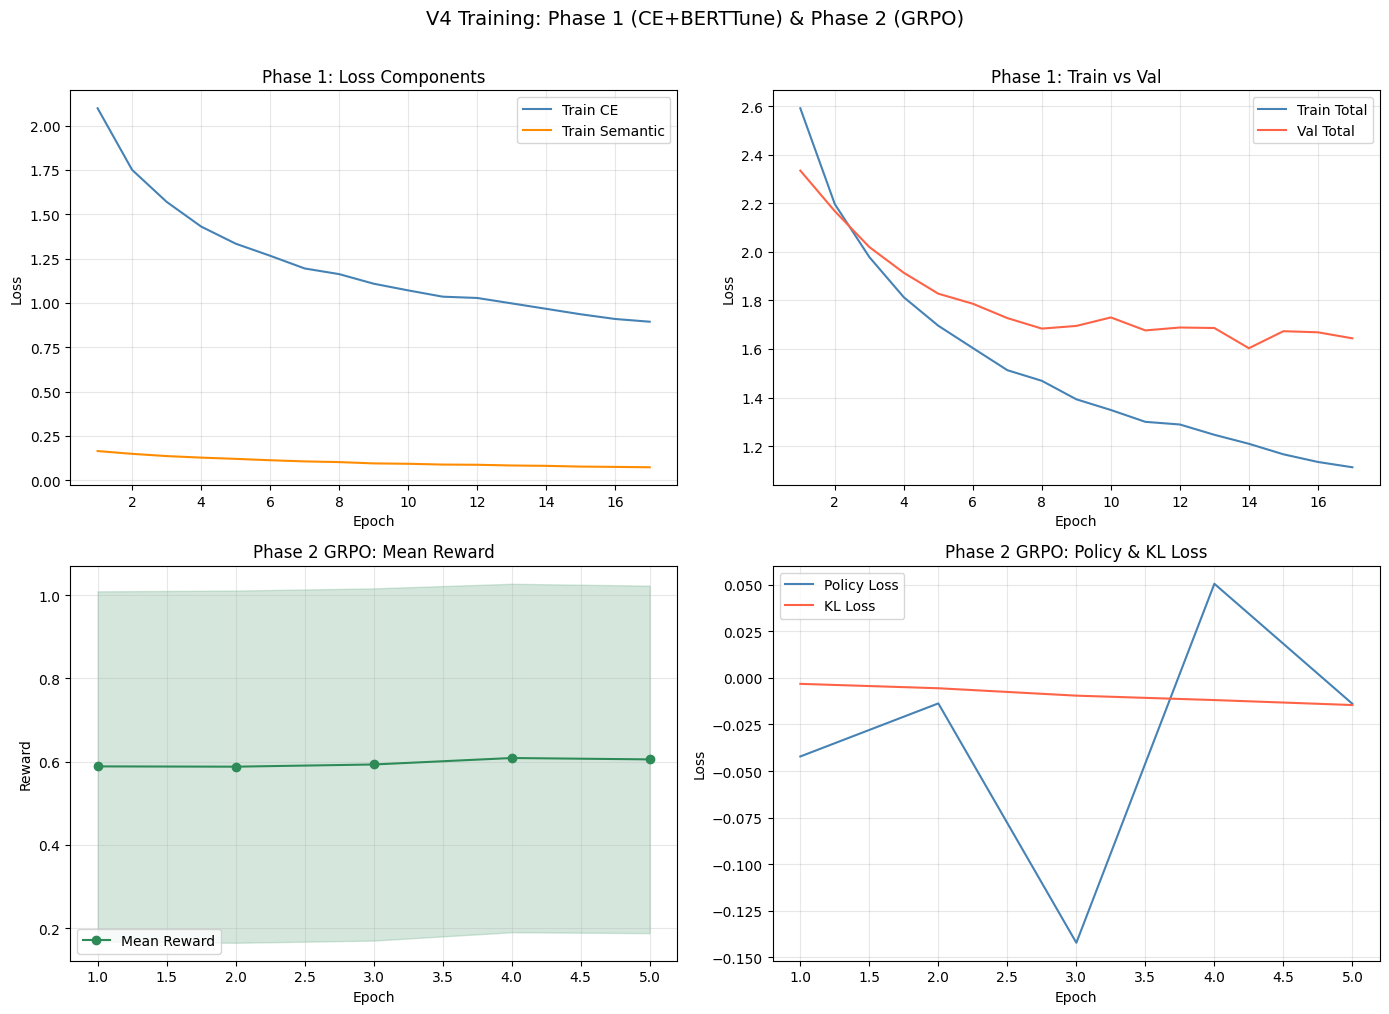

In [13]:
# ── Training Loss Plots ───────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Phase 1 plots ──
epochs_p1 = range(1, len(phase1_history["train_total"]) + 1)

ax = axes[0][0]
ax.plot(epochs_p1, phase1_history["train_ce"],  label="Train CE",      color="steelblue")
ax.plot(epochs_p1, phase1_history["train_sem"], label="Train Semantic", color="darkorange")
ax.set_title("Phase 1: Loss Components")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0][1]
ax.plot(epochs_p1, phase1_history["train_total"], label="Train Total", color="steelblue")
ax.plot(epochs_p1, phase1_history["val_loss"],    label="Val Total",   color="tomato")
ax.set_title("Phase 1: Train vs Val")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)

# ── Phase 2 GRPO plots ──
epochs_p2 = range(1, len(grpo_history["reward_mean"]) + 1)

ax = axes[1][0]
r_mean = grpo_history["reward_mean"]
r_std  = grpo_history["reward_std"]
ax.plot(epochs_p2, r_mean, color="seagreen", marker='o', label="Mean Reward")
ax.fill_between(epochs_p2,
                [m - s for m, s in zip(r_mean, r_std)],
                [m + s for m, s in zip(r_mean, r_std)],
                alpha=0.2, color="seagreen")
ax.set_title("Phase 2 GRPO: Mean Reward")
ax.set_xlabel("Epoch"); ax.set_ylabel("Reward")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1][1]
ax.plot(epochs_p2, grpo_history["policy_loss"], label="Policy Loss", color="steelblue")
ax.plot(epochs_p2, grpo_history["kl_loss"],     label="KL Loss",     color="tomato")
ax.set_title("Phase 2 GRPO: Policy & KL Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("V4 Training: Phase 1 (CE+BERTTune) & Phase 2 (GRPO)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Cell 13: Evaluation – Generate Answers

Greedy generation on train/eval/test splits using the GRPO-tuned adapter. Results saved as CSVs.

In [14]:
# ── Evaluation -- Generate Answers ─────────────────────────────────────────────

def evaluate_generation(cfg, model, tokenizer, adapter, data, concept_vecs,
                         split_name: str, max_new_tokens: int = 128):
    adapter.eval()
    layer   = model.model.layers[cfg.injection_layer]
    results = []

    for item in tqdm(data, desc=f"Gen | {split_name}"):
        vec = concept_vecs.get(item['entity_key'])
        if vec is None:
            generated = ""
        else:
            msgs       = [{"role": "user", "content": item['question']}]
            prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False,
                                                       add_generation_prompt=True)
            inputs = tokenizer(prompt_str, return_tensors="pt").to(model.device)

            with torch.no_grad():
                injection_vec = adapter(
                    vec.unsqueeze(0).to(model.device, dtype=cfg.torch_dtype)
                ).squeeze(0)

            inject_idx = inputs["input_ids"].shape[1] - 1

            def single_hook(module, args, output):
                hs = output[0] if isinstance(output, tuple) else output
                if inject_idx < hs.shape[1]:
                    hs[0, inject_idx, :] = hs[0, inject_idx, :] + injection_vec
                return (hs,) + output[1:] if isinstance(output, tuple) else hs

            handle = layer.register_forward_hook(single_hook)
            try:
                with torch.no_grad():
                    out_ids = model.generate(
                        **inputs,
                        max_new_tokens=max_new_tokens,
                        do_sample=False,
                        pad_token_id=tokenizer.eos_token_id
                    )
            finally:
                handle.remove()

            generated = tokenizer.decode(
                out_ids[0][inputs["input_ids"].shape[1]:],
                skip_special_tokens=True
            )

        results.append({
            "category":  item["category_key"],
            "word":      item["entity_original"],
            "question":  item["question"],
            "generated": generated,
            "expected":  item["answer"],
        })

    out_dir  = os.path.join(cfg.base_dir, f"architecture{cfg.architecture_id}")
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir,
        f"{split_name}_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}.csv")
    pd.DataFrame(results).to_csv(out_path, index=False)
    print(f"Saved {len(results)} results -> {out_path}")
    return results


# ── Run evaluation ────────────────────────────────────────────────────────────
# Reload GRPO adapter (in case we restart from here)
adapter = build_adapter(cfg, model).to(model.device, dtype=cfg.torch_dtype)
adapter.load_state_dict(torch.load(cfg.adapter_save_path_grpo, map_location=model.device))

eval_results = {
    "train": evaluate_generation(cfg, model, tokenizer, adapter,
                                 train_data, concept_vecs, "train"),
    "eval":  evaluate_generation(cfg, model, tokenizer, adapter,
                                 val_data, concept_vecs, "eval"),
    "test":  evaluate_generation(cfg, model, tokenizer, adapter,
                                 test_data, concept_vecs_test, "test"),
}

print("\nAll evaluations complete.")

Adapter (Architecture 4): 33,562,624 parameters


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Saved 1389 results -> results_v4/architecture4/train_results_L16_prompt1.csv


Saved 279 results -> results_v4/architecture4/eval_results_L16_prompt1.csv


Saved 154 results -> results_v4/architecture4/test_results_L16_prompt1.csv

All evaluations complete.


## Cell 14: LLM-as-a-Judge (Gemini 2.5 Flash) + Summary Table

Final evaluation using Gemini as the judge (same as V3). This is the authoritative evaluation,
separate from the Qwen judge used during GRPO training.

In [15]:
from typing_extensions import TypedDict
import json
import time
import os
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
from tqdm import tqdm
import google.generativeai as genai

# ── LLM-as-a-Judge (Gemini 2.5 Flash) ────────────────────────────────────────

class EvaluationResult(TypedDict):
    contains_entity: bool
    contains_entity_explanation: str
    matches_reference: bool
    matches_reference_explanation: str

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
genai.configure(api_key=GEMINI_API_KEY)
gemini_judge = genai.GenerativeModel('gemini-2.5-flash')

EVALUATION_PROMPT = (
    "You are evaluating answers from a question-answering system.\n\n"
    "**Context:**\n"
    "- Entity: {word}\n"
    "- Question: {question}\n"
    "- Generated Answer: {generated}\n"
    "- Reference Answer: {expected}\n\n"
    "**Your Task:**\n"
    "Evaluate the generated answer on two dimensions:\n\n"
    "1. **Contains Entity**: Does the generated answer explicitly mention or reference the entity \"{word}\"?\n\n"
    "2. **Matches Reference**: Does the generated answer convey the same core information as the reference answer?\n"
    "   - They don't need to be word-for-word identical or even the same length.\n"
    "   - A short answer (even just the entity name) is correct if it provides the key information.\n"
    "   - Focus on whether the generated answer would be considered a correct response to the question."
)


def evaluate_single_row(row: dict) -> dict:
    prompt = EVALUATION_PROMPT.format(**row)
    try:
        response = gemini_judge.generate_content(
            prompt,
            generation_config=genai.GenerationConfig(
                response_mime_type="application/json",
                response_schema=EvaluationResult
            )
        )

        raw_text = response.text.strip()
        if raw_text.startswith("```json"):
            raw_text = raw_text[7:]
        if raw_text.startswith("```"):
            raw_text = raw_text[3:]
        if raw_text.endswith("```"):
            raw_text = raw_text[:-3]

        result = json.loads(raw_text.strip())
        return {
            "contains_entity":               result.get("contains_entity", False),
            "contains_entity_explanation":   result.get("contains_entity_explanation", ""),
            "matches_reference":             result.get("matches_reference", False),
            "matches_reference_explanation": result.get("matches_reference_explanation", ""),
        }
    except Exception as e:
        return {"contains_entity": False, "contains_entity_explanation": f"Error: {e}",
                "matches_reference": False, "matches_reference_explanation": f"Error: {e}"}


def evaluate_csv(csv_path: str) -> pd.DataFrame:
    out_path = csv_path.replace(".csv", "_evaluated.csv")
    df = pd.read_csv(csv_path)
    if os.path.exists(out_path) and 'contains_entity' in pd.read_csv(out_path).columns:
        print(f"  Already evaluated: {out_path}")
        return pd.read_csv(out_path)
    evals = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="  LLM-as-judge"):
        evals.append(evaluate_single_row(row.to_dict()))
        time.sleep(0.5)
    for key in evals[0]:
        df[key] = [e[key] for e in evals]
    df.to_csv(out_path, index=False)
    print(f"  Saved: {out_path}")
    return df


# Run judge on all splits
SPLITS = ["train", "eval", "test"]
summary = {}

arch_dir = os.path.join(cfg.base_dir, f"architecture{cfg.architecture_id}")

print(f"\n{'='*60}")
print(f"  Gemini Judge — Architecture {cfg.architecture_id}")
print(f"{'='*60}")

for split in SPLITS:
    csv_path = os.path.join(arch_dir,
        f"{split}_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}.csv")
    if os.path.exists(csv_path):
        df  = evaluate_csv(csv_path)
        ce  = 100 * pd.to_numeric(df['contains_entity'], errors='coerce').mean()
        mr  = 100 * pd.to_numeric(df['matches_reference'], errors='coerce').mean()
        summary[split] = (ce, mr)
        print(f"  {split:6s}: CE={ce:.1f}%  MR={mr:.1f}%")
    else:
        print(f"  {split:6s}: file not found")

# Summary table
print(f"\n{'='*40}")
print(f"{'RESULTS SUMMARY':^40}")
print(f"{'='*40}")
print(f"{'Split':<8}  {'CE':>8}  {'MR':>8}")
print("-"*40)
for split in SPLITS:
    s = summary.get(split, (float('nan'), float('nan')))
    print(f"{split:<8}  {s[0]:>7.1f}%  {s[1]:>7.1f}%")


  Gemini Judge — Architecture 4


  LLM-as-judge:   8%|▊         | 106/1389 [06:16<1:19:37,  3.72s/it]ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2036.21ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1182.48ms
  LLM-as-judge:  20%|██        | 284/1389 [16:28<1:07:33,  3.67s/it]ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1106.74ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1407.85ms
  LLM-as-judge:  35%|███▌      | 491/1389 [28:21<47:07,  3.15s/it]ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 880.99ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1107.32ms
  LLM-as-judge:  40%|███▉      

  Saved: results_v4/architecture4/train_results_L16_prompt1_evaluated.csv
  train : CE=88.5%  MR=84.8%


  LLM-as-judge:  35%|███▍      | 97/279 [06:00<12:46,  4.21s/it]ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2088.10ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1031.50ms
  LLM-as-judge:  38%|███▊      | 106/279 [06:36<10:50,  3.76s/it]ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1408.78ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 4950.18ms
  LLM-as-judge:  41%|████      | 114/279 [07:10<09:53,  3.60s/it]ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 980.64ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 980.80ms
  LLM-as-judge: 100%|██████████| 279/279

  Saved: results_v4/architecture4/eval_results_L16_prompt1_evaluated.csv
  eval  : CE=83.5%  MR=79.6%


  LLM-as-judge: 100%|██████████| 154/154 [09:05<00:00,  3.54s/it]

  Saved: results_v4/architecture4/test_results_L16_prompt1_evaluated.csv
  test  : CE=29.2%  MR=24.7%

            RESULTS SUMMARY             
Split           CE        MR
----------------------------------------
train        88.5%     84.8%
eval         83.5%     79.6%
test         29.2%     24.7%


## Cell 15: Results Visualization

Category-level bar charts for each split (train / eval / test).

Plot saved: results_v4/evaluation_plots/arch4_train_L16_evaluation.png


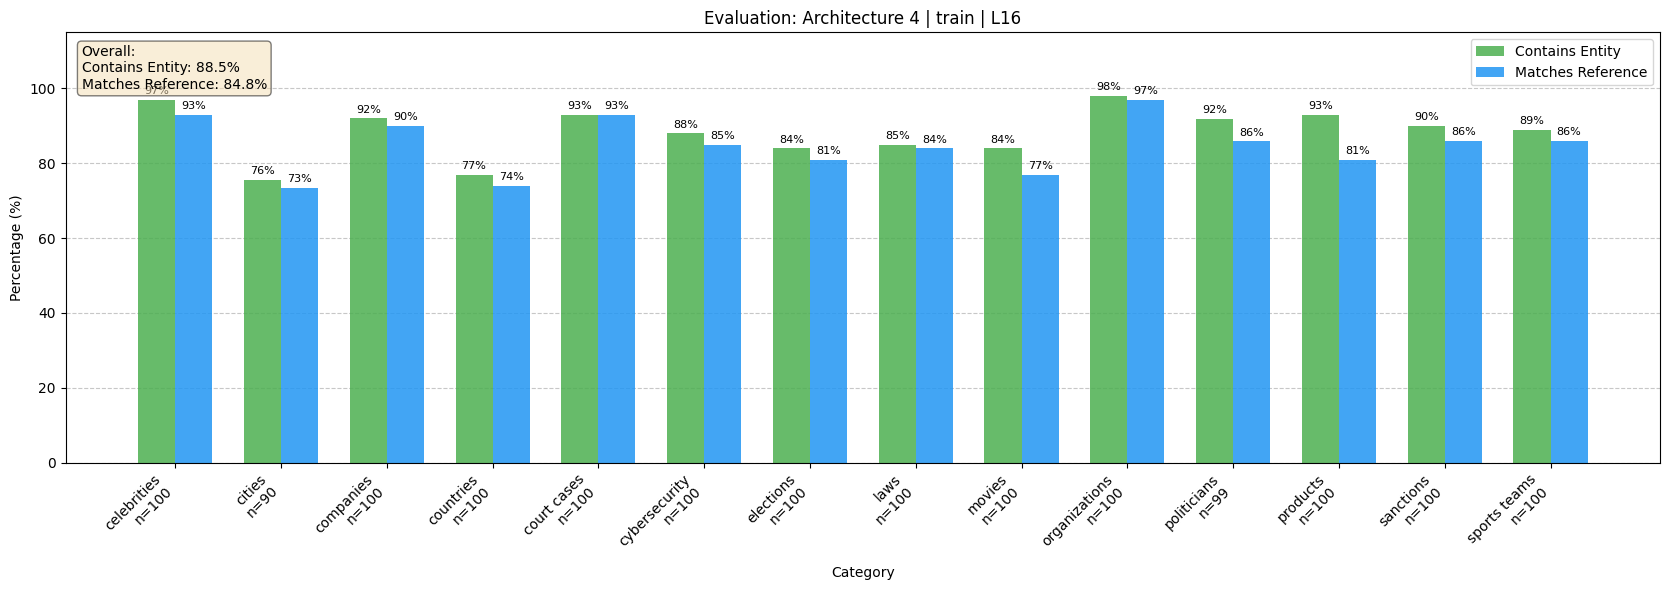

Plot saved: results_v4/evaluation_plots/arch4_eval_L16_evaluation.png


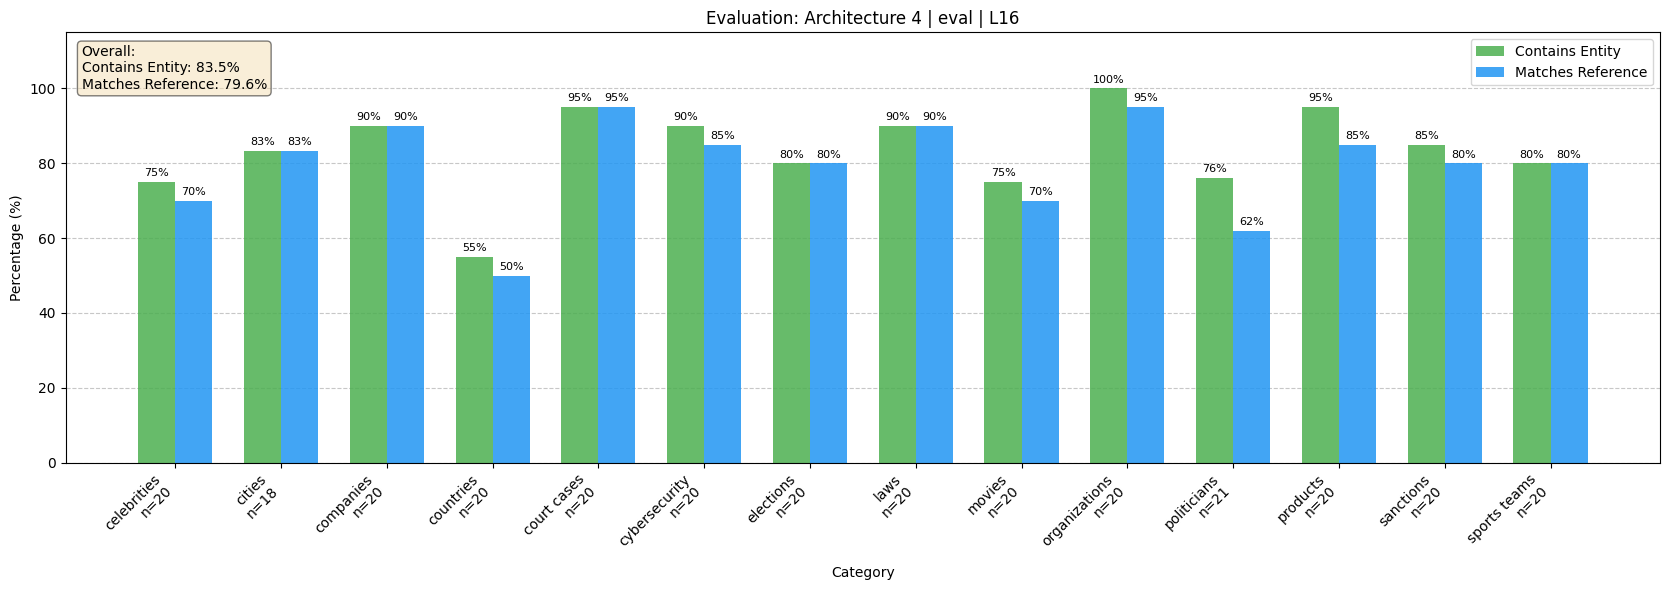

Plot saved: results_v4/evaluation_plots/arch4_test_L16_evaluation.png


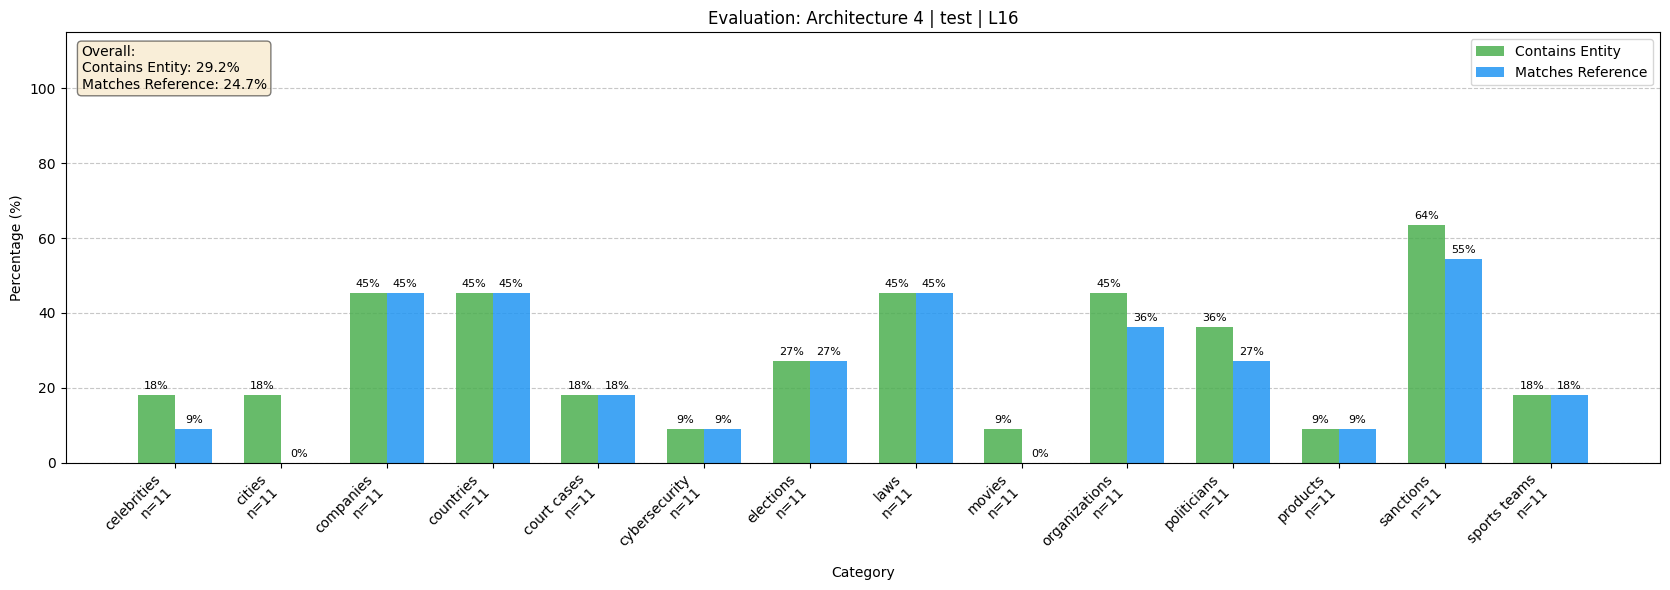

In [11]:
# ── Results Visualization ──────────────────────────────────────────────────────

PLOTS_DIR = os.path.join(cfg.base_dir, "evaluation_plots")
os.makedirs(PLOTS_DIR, exist_ok=True)


def plot_evaluation_by_category(cfg, split: str):
    arch_dir = os.path.join(cfg.base_dir, f"architecture{cfg.architecture_id}")
    fname    = f"{split}_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}_evaluated.csv"
    csv_path = os.path.join(arch_dir, fname)

    if not os.path.exists(csv_path):
        print(f"File not found: {csv_path}")
        return None

    df = pd.read_csv(csv_path)
    if 'contains_entity' not in df.columns:
        print(f"Run LLM judge first on: {csv_path}")
        return None

    cat_metrics = df.groupby('category').agg(
        ce_pct = ('contains_entity',  lambda x: 100 * x.mean()),
        mr_pct = ('matches_reference', lambda x: 100 * x.mean()),
        count  = ('category', 'size')
    ).reset_index().sort_values('category')

    cats = cat_metrics['category'].tolist()
    x    = np.arange(len(cats))
    w    = 0.35

    fig, ax = plt.subplots(figsize=(max(12, len(cats) * 1.2), 6))
    b1 = ax.bar(x - w/2, cat_metrics['ce_pct'], w, label='Contains Entity',   color='#4CAF50', alpha=0.85)
    b2 = ax.bar(x + w/2, cat_metrics['mr_pct'], w, label='Matches Reference', color='#2196F3', alpha=0.85)

    for bar in [*b1, *b2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)

    overall_ce = 100 * df['contains_entity'].mean()
    overall_mr = 100 * df['matches_reference'].mean()

    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}\nn={n}" for c, n in zip(cats, cat_metrics['count'])],
                       rotation=45, ha='right')
    ax.set_ylim(0, 115)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('Category')
    ax.set_title(f'Evaluation: Architecture {cfg.architecture_id} | {split} | L{cfg.injection_layer}')
    ax.legend(loc='upper right')
    ax.text(0.01, 0.97,
            f'Overall:\nContains Entity: {overall_ce:.1f}%\nMatches Reference: {overall_mr:.1f}%',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    plt.tight_layout()

    out = os.path.join(PLOTS_DIR, f"arch{cfg.architecture_id}_{split}_L{cfg.injection_layer}_evaluation.png")
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f"Plot saved: {out}")
    plt.show()
    plt.close()
    return cat_metrics


for split in ["train", "eval", "test"]:
    plot_evaluation_by_category(cfg, split)